[INFO] Loading files...
[INFO] Building SOLVPN-COPPER event-level pair features...
[INFO] Building daily SOLVPN-COPPER pair spillover series...
[SAVED] result\dc_copper_daily_pair_series.csv
[INFO] Merging event-level features...
[INFO] Identifying Data Center events from spillover structure...
[INFO] Building analysis tables...
[INFO] Saving outputs...
[SAVED] result\dc_event_master.csv
[SAVED] result\dc_vs_non_dc_summary.csv
[SAVED] result\analysis_summary.csv
[SAVED] result\dc_event_type_counts.csv
[SAVED] result\dc_cluster_counts.csv
[SAVED] result\dc_direction_counts.csv
[INFO] Drawing daily pair spillover series...


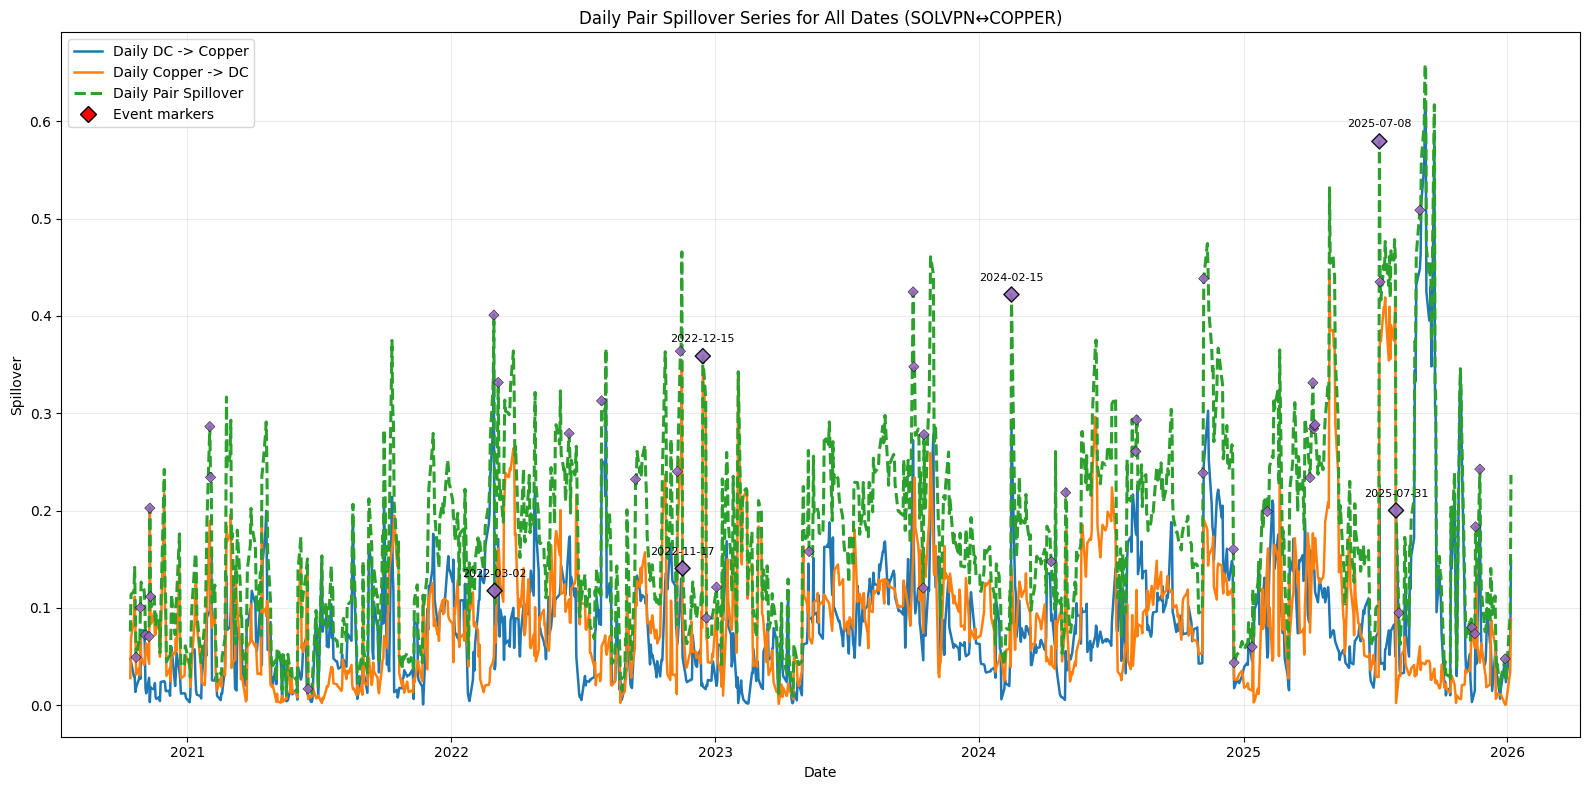

[SAVED] result\daily_pair_spillover_series.png
[INFO] Drawing DC->CP minus CP->DC spread series...


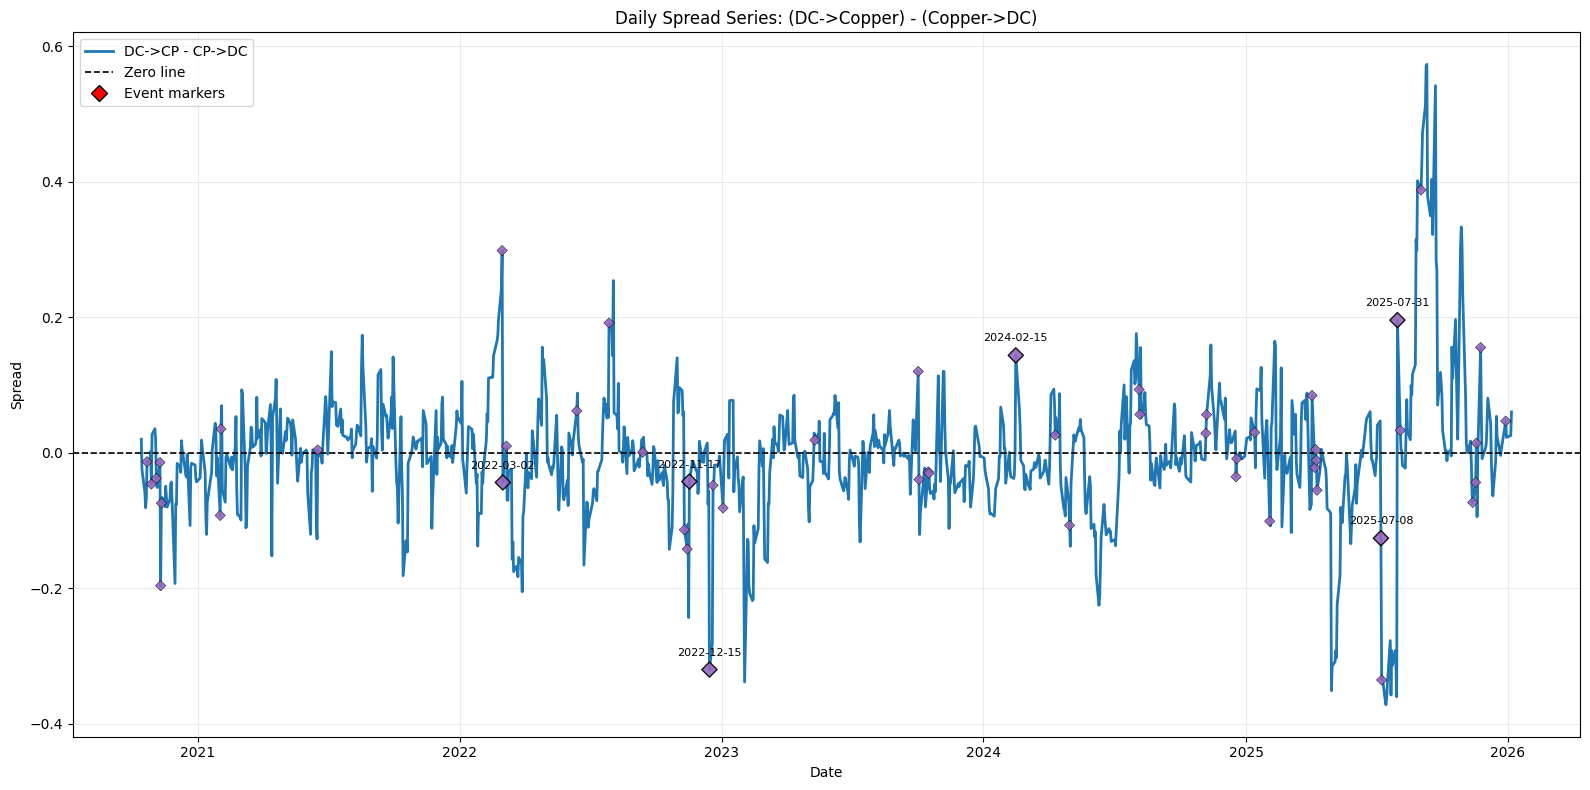

[SAVED] result\daily_spread_dc_to_cp_minus_cp_to_dc.png
[INFO] Drawing event-level plots...



[SUMMARY]
Total events      : 52
DC events         : 6
DC event ratio    : 0.115
PairImpact cutoff : 0.263100

[TOP DC EVENTS]
      Date                           EventLabel             DC_EventType  PairImpact  DC_to_CP  CP_to_DC       AUC  HalfLife ClusterLabel
2025-07-31                   미국 정제동을 관세 대상에서 제외  Copper_Supply_Transient    0.556208  0.147746  0.408462 11.139793       2.0   Unassigned
2025-07-08                 트럼프의 구리 50% 관세 방침 발표  Copper_Supply_Transient    0.474640  0.150716  0.323924 14.309733       2.0   Unassigned
2022-03-02                   러-우 전쟁 초기, 안전자산 확대     DC_Demand_Structural    0.342433  0.312902  0.029532 22.530986       2.0   Unassigned
2024-02-15 미국 인플레이션·소매판매 지표로 인해 rate cut 기대 흔들림      DC_Demand_Transient    0.341299  0.241353  0.099946  6.693508       2.0   Unassigned
2022-11-17         달러 반등과 Fed의 추가 긴축 발언으로 금이 후퇴  Copper_Supply_Transient    0.325269  0.062147  0.263122 10.191637       1.0   Unassigned
2022-12-15         Fed 금리 경로 경계 속에서도 중국 리오프닝

In [9]:
import numpy as np
import pandas as pd
from pathlib import Path
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# Local VS Code
# ============================================================
pio.renderers.default = "vscode"

BASE_DIR = Path("./")
RESULT_DIR = BASE_DIR / "result"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Files
# ============================================================
FILE_EVENTS = BASE_DIR / "events_window0.csv"
FILE_CLUSTERS = BASE_DIR / "event_clusters_final.csv"
FILE_PERSIST = BASE_DIR / "event_persistence_window0.csv"
FILE_SUMMARY = BASE_DIR / "event_quantification_window0_summary.csv"
FILE_PAIRWISE = BASE_DIR / "event_quantification_window0_pairwise_long.csv"

# 추가: 모든 date에 대한 pair spillover series 계산용
FILE_GFEVD = BASE_DIR / "gfevd_all.npy"
FILE_INPUT = BASE_DIR / "tvpvar_input_scaled.csv"

# ============================================================
# Config
# ============================================================
DC_VAR = "SOLVPN"
CP_VAR = "COPPER"

FEATURES = ["SOLVPN", "COPPER", "GOLD", "SILVER", "DXY", "UST10Y", "VIX"]
IDX = {v: i for i, v in enumerate(FEATURES)}

# Data Center event = SOLVPN↔COPPER pair spillover가 비정상적으로 큰 event
DC_EVENT_Q = 0.90
STRUCTURAL_Q = 0.75
ASYM_EPS_RATIO = 0.10

# cluster color
CLUSTER_COLOR_MAP = {
    "Structural Persistent": "#d62728",
    "Transient Shock": "#1f77b4",
    "Delayed Response": "#2ca02c",
    "Minor": "#7f7f7f",
    "Unassigned": "#9467bd",
}

# User-provided labels
EVENT_LABELS = {
    "2020-11-09": "코로나 백신 발표로 인한 경기 회복 기대, 금/은 안전자산 가격 급락",
    "2024-08-05": "미국 경기둔화·침체 우려가 촉발한 글로벌 위험자산 매도",
    "2024-12-18": "Fed 정책결정 대기와 금리경로 재평가",
    "2025-07-08": "트럼프의 구리 50% 관세 방침 발표",
    "2025-07-31": "미국 정제동을 관세 대상에서 제외",
    "2020-10-22": "미국 경기지표 개선과 달러 반등으로 금·은 약세",
    "2020-10-28": "유럽·미국의 코로나 재확산과 봉쇄 우려",
    "2020-11-04": "미국 대선 개표",
    "2021-02-01": "실버 스퀴즈 발생",
    "2021-06-17": "FOMC 이후 달러 급등과 조기 긴축 기대가 강화, 금은구리 동시 급락",
    "2022-03-01": "러시아-우크라이나 전쟁 초기 충격",
    "2022-03-07": "전쟁 충격이 더 커지며 LME 금속시장 전반 영향",
    "2022-06-13": "미국 CPI 충격 직후로, 인플레이션과 긴축 우려",
    "2022-07-28": "recession fear, 경제 성장 둔화나 마이너스 성장이 예상될 때 투자자나 대중이 느끼는 불안",
    "2022-11-10": "미국 CPI가 예상보다 낮게 나오며 Fed 속도조절 기대",
    "2022-11-17": "달러 반등과 Fed의 추가 긴축 발언으로 금이 후퇴",
    "2022-12-20": "중국 리오프닝 기대",
    "2023-01-03": "중국 리오프닝과 달러 약세 기대",
    "2023-05-11": "중국 수요 둔화·미국 부채한도 불안, 생성형 AI 인프라 투자 확대 기대",
    "2023-10-02": "파나마의 First Quantum 신규 광산계약 논의 중단",
    "2023-10-16": "geopolitical safe-haven bid, 지정학적 안전자산 선호 현상",
    "2024-02-15": "미국 인플레이션·소매판매 지표로 인해 rate cut 기대 흔들림",
    "2024-04-10": "중국 경기지표 개선과 원료 부족 우려로 강세",
    "2024-04-30": "AI·데이터센터가 2030년까지 구리 수요를 100만 톤 추가할 수 있다는 전망",
    "2024-11-06": "미국 대선에서 트럼프 승리가 확정",
    "2025-01-13": "LME가 2022 니켈 위기 후 거래 회복을 확인",
    "2025-02-03": "무역불안에 따른 금 강세, 구조적 구리 수요 테마 명확",
    "2025-04-03": "트럼프의 공격적 관세 발표로 금은 사상 최고치, 구리는 경기둔화 우려로 약세",
    "2025-11-13": "미국 셧다운 종료와 더 비둘기파적인 금리 기대 속 금과 은이 상승",
    "2025-12-29": "금·은이 급등 후 변동성 확대, 구리는 글로벌 공급부족 우려로 15년 만의 최대 연간 상승폭",
    "2022-03-02": "러-우 전쟁 초기, 안전자산 확대",
    "2022-09-13": "미국 CPI 쇼크 (인플레이션 재상승)",
    "2022-12-15": "Fed 금리 경로 경계 속에서도 중국 리오프닝 기대",
    "2025-04-08": "미·중 무역갈등 재격화와 관세 불안, AI와 DC가 2030년까지 구리 수요를 100만 톤 추가",
    "2025-07-09": "트럼프의 구리 50% 관세 방침 발표",
    "2025-09-02": "금은 달러·장기금리·재정 불안 속 사상 최고권, 구리는 달러 약세와 중국 지표로 2개월 고점",
    "2025-11-17": "중앙은행의 지속적 금 매수 전망",
    "2025-11-24": "UBS의 구리 전망 상향",
}

# ============================================================
# Helpers
# ============================================================
def load_csv(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    df = pd.read_csv(path)
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
    return df

def safe_merge(left, right, on="Date", suffix="_dup"):
    overlap = [c for c in right.columns if c != on and c in left.columns]
    if overlap:
        right = right.rename(columns={c: f"{c}{suffix}" for c in overlap})
    return pd.merge(left, right, on=on, how="left")

def first_nonnull(df, cols, default=np.nan):
    out = pd.Series(default, index=df.index)
    for c in cols:
        if c in df.columns:
            out = out.where(~out.isna(), df[c])
    return out

def choose_label_column(df):
    preferred = ["EventLabel", "Label", "Event", "EventName", "Description", "EventDescription", "Title", "Name"]
    for c in preferred:
        if c in df.columns:
            return c
    obj_cols = [c for c in df.columns if c != "Date" and str(df[c].dtype) == "object"]
    return obj_cols[0] if obj_cols else None

def classify_direction(dc_to_cp, cp_to_dc, pair_impact, eps_ratio=0.10):
    if pd.isna(pair_impact) or pair_impact == 0:
        return "NoPairSignal"
    gap = dc_to_cp - cp_to_dc
    if abs(gap) <= eps_ratio * pair_impact:
        return "Bidirectional"
    return "DC_to_Copper" if gap > 0 else "Copper_to_DC"

def classify_persistence(auc_rank, hl_rank, structural_q=0.75):
    if pd.isna(auc_rank) and pd.isna(hl_rank):
        return "Unknown"
    cond_auc = (not pd.isna(auc_rank)) and (auc_rank >= structural_q)
    cond_hl = (not pd.isna(hl_rank)) and (hl_rank >= structural_q)
    return "Structural" if (cond_auc or cond_hl) else "Transient"

def classify_dc_event_type(is_dc, direction_type, persistence_type):
    if not is_dc:
        return "Non_DC_Event"
    if persistence_type == "Structural":
        if direction_type == "DC_to_Copper":
            return "DC_Demand_Structural"
        if direction_type == "Copper_to_DC":
            return "Copper_Supply_Structural"
        return "Bidirectional_Structural"
    else:
        if direction_type == "DC_to_Copper":
            return "DC_Demand_Transient"
        if direction_type == "Copper_to_DC":
            return "Copper_Supply_Transient"
        return "Bidirectional_Transient"

def summary_stats(df, group_col, value_cols):
    rows = []
    for g, sub in df.groupby(group_col):
        row = {group_col: g, "N": len(sub)}
        for c in value_cols:
            row[f"{c}_mean"] = pd.to_numeric(sub[c], errors="coerce").mean()
            row[f"{c}_median"] = pd.to_numeric(sub[c], errors="coerce").median()
        rows.append(row)
    return pd.DataFrame(rows)

def build_daily_pair_series(gfevd_all, df_input, feature_idx):
    df_input = df_input.sort_values("Date").reset_index(drop=True)
    n_input = len(df_input)
    n_gfevd = gfevd_all.shape[0]

    if n_input == n_gfevd:
        df_aligned = df_input.copy()
    elif n_input == n_gfevd + 1:
        df_aligned = df_input.iloc[1:].reset_index(drop=True)
    else:
        raise ValueError(f"Cannot align daily dates automatically: len(input)={n_input}, len(gfevd)={n_gfevd}")

    dc_idx = feature_idx[DC_VAR]
    cp_idx = feature_idx[CP_VAR]

    rows = []
    for t in range(n_gfevd):
        m = np.asarray(gfevd_all[t], dtype=float)
        dc_to_cp = float(m[dc_idx, cp_idx])
        cp_to_dc = float(m[cp_idx, dc_idx])
        pair_spill = abs(dc_to_cp) + abs(cp_to_dc)
        rows.append({
            "Date": pd.to_datetime(df_aligned.loc[t, "Date"]),
            "DC_to_CP": dc_to_cp,
            "CP_to_DC": cp_to_dc,
            "PairSpillover": pair_spill,
            "Asymmetry": dc_to_cp - cp_to_dc,
        })

    return pd.DataFrame(rows).sort_values("Date").reset_index(drop=True)

# ============================================================
# Load
# ============================================================
print("[INFO] Loading files...")

df_events = load_csv(FILE_EVENTS)
df_clusters = load_csv(FILE_CLUSTERS)
df_persist = load_csv(FILE_PERSIST)
df_summary = load_csv(FILE_SUMMARY)
df_pairwise = load_csv(FILE_PAIRWISE)

gfevd_all = np.load(FILE_GFEVD, allow_pickle=True)
df_input = load_csv(FILE_INPUT)

# ============================================================
# Base event table + labels
# ============================================================
df_events = df_events.sort_values("Date").reset_index(drop=True)
raw_label_col = choose_label_column(df_events)

df_events["EventLabel"] = df_events["Date"].dt.strftime("%Y-%m-%d").map(EVENT_LABELS)
if raw_label_col is not None:
    df_events["EventLabel"] = df_events["EventLabel"].fillna(df_events[raw_label_col].astype(str))
df_events["EventLabel"] = df_events["EventLabel"].fillna(df_events["Date"].dt.strftime("%Y-%m-%d"))

# ============================================================
# Pairwise spillover: SOLVPN <-> COPPER (event-level)
# ============================================================
print("[INFO] Building SOLVPN-COPPER event-level pair features...")

required_cols = {"Date", "From", "To", "DeltaS"}
missing_cols = required_cols - set(df_pairwise.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in pairwise file: {missing_cols}")

df_pairwise["Date"] = pd.to_datetime(df_pairwise["Date"])

mask = (
    ((df_pairwise["From"] == DC_VAR) & (df_pairwise["To"] == CP_VAR)) |
    ((df_pairwise["From"] == CP_VAR) & (df_pairwise["To"] == DC_VAR))
)
df_pair = df_pairwise.loc[mask].copy()
if df_pair.empty:
    raise ValueError("No SOLVPN/COPPER pair rows found in event_quantification_window0_pairwise_long.csv")

pair_rows = []
for dt, g in df_pair.groupby("Date"):
    s_dc_cp = g.loc[(g["From"] == DC_VAR) & (g["To"] == CP_VAR), "DeltaS"]
    s_cp_dc = g.loc[(g["From"] == CP_VAR) & (g["To"] == DC_VAR), "DeltaS"]

    dc_to_cp = float(s_dc_cp.sum()) if len(s_dc_cp) > 0 else 0.0
    cp_to_dc = float(s_cp_dc.sum()) if len(s_cp_dc) > 0 else 0.0
    pair_impact = float(s_dc_cp.abs().sum() + s_cp_dc.abs().sum())

    pair_rows.append({
        "Date": dt,
        "DC_to_CP": dc_to_cp,
        "CP_to_DC": cp_to_dc,
        "PairImpact": pair_impact,
        "Asymmetry": dc_to_cp - cp_to_dc,
        "DC_to_CP_PeakAbs": float(s_dc_cp.abs().max()) if len(s_dc_cp) > 0 else 0.0,
        "CP_to_DC_PeakAbs": float(s_cp_dc.abs().max()) if len(s_cp_dc) > 0 else 0.0,
    })

df_pair_event = pd.DataFrame(pair_rows).sort_values("Date").reset_index(drop=True)

# ============================================================
# Daily pair spillover series
# ============================================================
print("[INFO] Building daily SOLVPN-COPPER pair spillover series...")

df_daily = build_daily_pair_series(gfevd_all, df_input, IDX)
df_daily["Spread_DC_minus_CP"] = df_daily["DC_to_CP"] - df_daily["CP_to_DC"]
df_daily.to_csv(RESULT_DIR / "dc_copper_daily_pair_series.csv", index=False)
print(f"[SAVED] {RESULT_DIR / 'dc_copper_daily_pair_series.csv'}")

# ============================================================
# Merge persistence / summary / cluster
# ============================================================
print("[INFO] Merging event-level features...")

df_master = df_events.copy()
df_master = safe_merge(df_master, df_pair_event, on="Date", suffix="_pair")
df_master = safe_merge(df_master, df_summary, on="Date", suffix="_summary")
df_master = safe_merge(df_master, df_persist, on="Date", suffix="_persist")
df_master = safe_merge(df_master, df_clusters, on="Date", suffix="_cluster")

df_master["Magnitude"] = first_nonnull(df_master, ["Magnitude_cluster", "Magnitude_summary", "Magnitude"])
df_master["Peak"] = first_nonnull(df_master, ["Peak_cluster", "Peak_persist", "Peak"])
df_master["PeakHorizon"] = first_nonnull(df_master, ["PeakHorizon_cluster", "PeakHorizon_persist", "PeakHorizon"])
df_master["HalfLife"] = first_nonnull(df_master, ["HalfLife_cluster", "HalfLife_persist", "HalfLife"])
df_master["AUC"] = first_nonnull(df_master, ["AUC_cluster", "AUC_persist", "AUC"])
df_master["Cluster"] = first_nonnull(df_master, ["Cluster"])
df_master["ClusterLabel"] = first_nonnull(df_master, ["ClusterLabel"], default="Unassigned").fillna("Unassigned").astype(str)

# ranks for persistence classification
df_master["PairImpactRank"] = pd.to_numeric(df_master["PairImpact"], errors="coerce").rank(pct=True)
df_master["AUCRank"] = pd.to_numeric(df_master["AUC"], errors="coerce").rank(pct=True)
df_master["HalfLifeRank"] = pd.to_numeric(df_master["HalfLife"], errors="coerce").rank(pct=True)

# ============================================================
# DC event identification: spillover-structure-based
# ============================================================
print("[INFO] Identifying Data Center events from spillover structure...")

pair_threshold = pd.to_numeric(df_master["PairImpact"], errors="coerce").quantile(DC_EVENT_Q)

df_master["Is_DC_Event"] = pd.to_numeric(df_master["PairImpact"], errors="coerce") >= pair_threshold
df_master["DirectionType"] = df_master.apply(
    lambda r: classify_direction(
        pd.to_numeric(r["DC_to_CP"], errors="coerce"),
        pd.to_numeric(r["CP_to_DC"], errors="coerce"),
        pd.to_numeric(r["PairImpact"], errors="coerce"),
        eps_ratio=ASYM_EPS_RATIO
    ),
    axis=1
)
df_master["PersistenceType"] = df_master.apply(
    lambda r: classify_persistence(
        pd.to_numeric(r["AUCRank"], errors="coerce"),
        pd.to_numeric(r["HalfLifeRank"], errors="coerce"),
        structural_q=STRUCTURAL_Q
    ),
    axis=1
)
df_master["DC_EventType"] = df_master.apply(
    lambda r: classify_dc_event_type(
        bool(r["Is_DC_Event"]),
        r["DirectionType"],
        r["PersistenceType"]
    ),
    axis=1
)

df_master = df_master.sort_values(["Is_DC_Event", "PairImpact"], ascending=[False, False]).reset_index(drop=True)
df_master["ClusterColor"] = df_master["ClusterLabel"].map(CLUSTER_COLOR_MAP).fillna(CLUSTER_COLOR_MAP["Unassigned"])

# ============================================================
# Analysis tables
# ============================================================
print("[INFO] Building analysis tables...")

metric_cols = ["PairImpact", "DC_to_CP", "CP_to_DC", "Asymmetry", "Magnitude", "Peak", "PeakHorizon", "HalfLife", "AUC"]

df_compare = summary_stats(df_master, "Is_DC_Event", metric_cols)
df_type_count = (
    df_master.groupby(["Is_DC_Event", "DC_EventType"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Is_DC_Event", "Count"], ascending=[False, False])
)

df_cluster_count = (
    df_master.groupby(["Is_DC_Event", "ClusterLabel"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Is_DC_Event", "Count"], ascending=[False, False])
)

df_direction_count = (
    df_master.groupby(["Is_DC_Event", "DirectionType"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Is_DC_Event", "Count"], ascending=[False, False])
)

summary_rows = [
    {"Metric": "N_total_events", "Value": len(df_master)},
    {"Metric": "N_dc_events", "Value": int(df_master["Is_DC_Event"].sum())},
    {"Metric": "DC_event_quantile_threshold", "Value": DC_EVENT_Q},
    {"Metric": "PairImpact_threshold", "Value": pair_threshold},
    {"Metric": "Structural_quantile_threshold", "Value": STRUCTURAL_Q},
    {"Metric": "Asymmetry_eps_ratio", "Value": ASYM_EPS_RATIO},
]
df_summary_out = pd.DataFrame(summary_rows)

# ============================================================
# Save outputs
# ============================================================
print("[INFO] Saving outputs...")

master_cols = [
    "Date", "EventLabel",
    "Is_DC_Event", "DC_EventType", "DirectionType", "PersistenceType",
    "PairImpact", "DC_to_CP", "CP_to_DC", "Asymmetry",
    "Magnitude", "Peak", "PeakHorizon", "HalfLife", "AUC",
    "Cluster", "ClusterLabel"
]
master_cols = [c for c in master_cols if c in df_master.columns]

df_master[master_cols].sort_values("Date").to_csv(RESULT_DIR / "dc_event_master.csv", index=False)
df_compare.to_csv(RESULT_DIR / "dc_vs_non_dc_summary.csv", index=False)
df_summary_out.to_csv(RESULT_DIR / "analysis_summary.csv", index=False)
df_type_count.to_csv(RESULT_DIR / "dc_event_type_counts.csv", index=False)
df_cluster_count.to_csv(RESULT_DIR / "dc_cluster_counts.csv", index=False)
df_direction_count.to_csv(RESULT_DIR / "dc_direction_counts.csv", index=False)

print(f"[SAVED] {RESULT_DIR / 'dc_event_master.csv'}")
print(f"[SAVED] {RESULT_DIR / 'dc_vs_non_dc_summary.csv'}")
print(f"[SAVED] {RESULT_DIR / 'analysis_summary.csv'}")
print(f"[SAVED] {RESULT_DIR / 'dc_event_type_counts.csv'}")
print(f"[SAVED] {RESULT_DIR / 'dc_cluster_counts.csv'}")
print(f"[SAVED] {RESULT_DIR / 'dc_direction_counts.csv'}")

# ============================================================
# Plot 0: Daily pair spillover series for all dates
# ============================================================
print("[INFO] Drawing daily pair spillover series...")

fig_daily = go.Figure()

fig_daily.add_trace(go.Scatter(
    x=df_daily["Date"],
    y=df_daily["DC_to_CP"],
    mode="lines",
    name="Daily DC → Copper",
    line=dict(width=2)
))

fig_daily.add_trace(go.Scatter(
    x=df_daily["Date"],
    y=df_daily["CP_to_DC"],
    mode="lines",
    name="Daily Copper → DC",
    line=dict(width=2)
))

fig_daily.add_trace(go.Scatter(
    x=df_daily["Date"],
    y=df_daily["PairSpillover"],
    mode="lines",
    name="Daily Pair Spillover",
    line=dict(width=2, dash="dash")
))

daily_event_overlay = df_master.sort_values("Date").copy()
daily_event_overlay = daily_event_overlay.merge(
    df_daily[["Date", "PairSpillover"]],
    on="Date",
    how="left"
)

for cluster_label, sub in daily_event_overlay.groupby("ClusterLabel"):
    fig_daily.add_trace(go.Scatter(
        x=sub["Date"],
        y=sub["PairSpillover"],
        mode="markers",
        name=f"Events - {cluster_label}",
        marker=dict(
            size=np.where(sub["Is_DC_Event"], 11, 7),
            color=sub["ClusterColor"],
            symbol=np.where(sub["Is_DC_Event"], "diamond", "circle"),
            line=dict(width=np.where(sub["Is_DC_Event"], 1.2, 0.5), color="black")
        ),
        customdata=np.stack([
            sub["EventLabel"].astype(str),
            sub["DC_EventType"].astype(str),
            sub["DirectionType"].astype(str),
            sub["PersistenceType"].astype(str),
            sub["DC_to_CP"].astype(float),
            sub["CP_to_DC"].astype(float),
            sub["PairImpact"].astype(float),
            sub["AUC"].astype(float) if "AUC" in sub.columns else np.full(len(sub), np.nan),
            sub["HalfLife"].astype(float) if "HalfLife" in sub.columns else np.full(len(sub), np.nan),
        ], axis=1),
        hovertemplate=(
            "<b>Date</b>: %{x|%Y-%m-%d}<br>"
            "<b>Event</b>: %{customdata[0]}<br>"
            "<b>DC Event Type</b>: %{customdata[1]}<br>"
            "<b>Direction</b>: %{customdata[2]}<br>"
            "<b>Persistence</b>: %{customdata[3]}<br>"
            "<b>Daily Pair Spillover</b>: %{y:.4f}<br>"
            "<b>Event DC → Copper</b>: %{customdata[4]:.4f}<br>"
            "<b>Event Copper → DC</b>: %{customdata[5]:.4f}<br>"
            "<b>Event PairImpact</b>: %{customdata[6]:.4f}<br>"
            "<b>AUC</b>: %{customdata[7]:.4f}<br>"
            "<b>HalfLife</b>: %{customdata[8]:.1f}<extra></extra>"
        ),
        showlegend=False
    ))

fig_daily.update_layout(
    title="Daily Pair Spillover Series for All Dates (SOLVPN↔COPPER)",
    xaxis_title="Date",
    yaxis_title="Spillover",
    template="plotly_white",
    height=600
)
fig_daily.show()

daily_png_path = RESULT_DIR / "daily_pair_spillover_series.png"

fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(df_daily["Date"], df_daily["DC_to_CP"], linewidth=1.8, label="Daily DC -> Copper")
ax.plot(df_daily["Date"], df_daily["CP_to_DC"], linewidth=1.8, label="Daily Copper -> DC")
ax.plot(df_daily["Date"], df_daily["PairSpillover"], linewidth=2.2, linestyle="--", label="Daily Pair Spillover")

for cluster_label, sub in daily_event_overlay.groupby("ClusterLabel"):
    ax.scatter(
        sub["Date"],
        sub["PairSpillover"],
        s=np.where(sub["Is_DC_Event"], 60, 28),
        c=sub["ClusterColor"],
        edgecolors="black",
        linewidths=np.where(sub["Is_DC_Event"], 1.0, 0.35),
        marker="D",
        alpha=0.9,
        zorder=3
    )

top_daily_dc = daily_event_overlay.loc[daily_event_overlay["Is_DC_Event"]].sort_values("PairSpillover", ascending=False).head(8)
for _, r in top_daily_dc.iterrows():
    ax.annotate(
        r["Date"].strftime("%Y-%m-%d"),
        xy=(r["Date"], r["PairSpillover"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

legend_handles = [
    Line2D([0], [0], color="C0", lw=1.8, label="Daily DC -> Copper"),
    Line2D([0], [0], color="C1", lw=1.8, label="Daily Copper -> DC"),
    Line2D([0], [0], color="C2", lw=2.2, linestyle="--", label="Daily Pair Spillover"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="red", markeredgecolor="black", markersize=8, label="Event markers"),
]
ax.legend(handles=legend_handles, loc="best")
ax.set_title("Daily Pair Spillover Series for All Dates (SOLVPN↔COPPER)")
ax.set_xlabel("Date")
ax.set_ylabel("Spillover")
ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(daily_png_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"[SAVED] {daily_png_path}")

# ============================================================
# Plot 0-2: DC->CP - CP->DC spread series (NEW)
# ============================================================
print("[INFO] Drawing DC->CP minus CP->DC spread series...")

fig_spread = go.Figure()

fig_spread.add_trace(go.Scatter(
    x=df_daily["Date"],
    y=df_daily["Spread_DC_minus_CP"],
    mode="lines",
    name="DC→CP - CP→DC",
    line=dict(width=2)
))

fig_spread.add_hline(y=0, line_width=1.2, line_dash="dash", line_color="black")

spread_event_overlay = df_master.sort_values("Date").copy()
spread_event_overlay = spread_event_overlay.merge(
    df_daily[["Date", "Spread_DC_minus_CP"]],
    on="Date",
    how="left"
)

for cluster_label, sub in spread_event_overlay.groupby("ClusterLabel"):
    fig_spread.add_trace(go.Scatter(
        x=sub["Date"],
        y=sub["Spread_DC_minus_CP"],
        mode="markers",
        name=f"Spread events - {cluster_label}",
        marker=dict(
            size=np.where(sub["Is_DC_Event"], 11, 7),
            color=sub["ClusterColor"],
            symbol=np.where(sub["Is_DC_Event"], "diamond", "circle"),
            line=dict(width=np.where(sub["Is_DC_Event"], 1.2, 0.5), color="black")
        ),
        customdata=np.stack([
            sub["EventLabel"].astype(str),
            sub["DC_EventType"].astype(str),
            sub["DirectionType"].astype(str),
            sub["PersistenceType"].astype(str),
            sub["DC_to_CP"].astype(float),
            sub["CP_to_DC"].astype(float),
            sub["PairImpact"].astype(float),
            sub["AUC"].astype(float) if "AUC" in sub.columns else np.full(len(sub), np.nan),
            sub["HalfLife"].astype(float) if "HalfLife" in sub.columns else np.full(len(sub), np.nan),
        ], axis=1),
        hovertemplate=(
            "<b>Date</b>: %{x|%Y-%m-%d}<br>"
            "<b>Event</b>: %{customdata[0]}<br>"
            "<b>DC Event Type</b>: %{customdata[1]}<br>"
            "<b>Direction</b>: %{customdata[2]}<br>"
            "<b>Persistence</b>: %{customdata[3]}<br>"
            "<b>Daily Spread</b>: %{y:.4f}<br>"
            "<b>Event DC → Copper</b>: %{customdata[4]:.4f}<br>"
            "<b>Event Copper → DC</b>: %{customdata[5]:.4f}<br>"
            "<b>Event PairImpact</b>: %{customdata[6]:.4f}<br>"
            "<b>AUC</b>: %{customdata[7]:.4f}<br>"
            "<b>HalfLife</b>: %{customdata[8]:.1f}<extra></extra>"
        ),
        showlegend=False
    ))

fig_spread.update_layout(
    title="Daily Spread Series: (DC→Copper) - (Copper→DC)",
    xaxis_title="Date",
    yaxis_title="Spread",
    template="plotly_white",
    height=600
)
fig_spread.show()

spread_png_path = RESULT_DIR / "daily_spread_dc_to_cp_minus_cp_to_dc.png"

fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(df_daily["Date"], df_daily["Spread_DC_minus_CP"], linewidth=2.0, label="DC->CP - CP->DC")
ax.axhline(0, linestyle="--", linewidth=1.2, color="black")

for cluster_label, sub in spread_event_overlay.groupby("ClusterLabel"):
    ax.scatter(
        sub["Date"],
        sub["Spread_DC_minus_CP"],
        s=np.where(sub["Is_DC_Event"], 60, 28),
        c=sub["ClusterColor"],
        edgecolors="black",
        linewidths=np.where(sub["Is_DC_Event"], 1.0, 0.35),
        marker="D",
        alpha=0.9,
        zorder=3
    )

top_spread_dc = spread_event_overlay.loc[spread_event_overlay["Is_DC_Event"]].copy()
top_spread_dc["AbsSpread"] = top_spread_dc["Spread_DC_minus_CP"].abs()
top_spread_dc = top_spread_dc.sort_values("AbsSpread", ascending=False).head(8)
for _, r in top_spread_dc.iterrows():
    ax.annotate(
        r["Date"].strftime("%Y-%m-%d"),
        xy=(r["Date"], r["Spread_DC_minus_CP"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

legend_handles = [
    Line2D([0], [0], color="C0", lw=2.0, label="DC->CP - CP->DC"),
    Line2D([0], [0], color="black", lw=1.2, linestyle="--", label="Zero line"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="red", markeredgecolor="black", markersize=8, label="Event markers"),
]
ax.legend(handles=legend_handles, loc="best")
ax.set_title("Daily Spread Series: (DC->Copper) - (Copper->DC)")
ax.set_xlabel("Date")
ax.set_ylabel("Spread")
ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(spread_png_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"[SAVED] {spread_png_path}")

# ============================================================
# Plot 1: Event-level PairImpact
# ============================================================
print("[INFO] Drawing event-level plots...")

plot_df = df_master.sort_values("Date").reset_index(drop=True)
top_dc = plot_df.loc[plot_df["Is_DC_Event"]].sort_values("PairImpact", ascending=False).copy()

fig1 = go.Figure()

for cluster_label, sub in plot_df.groupby("ClusterLabel"):
    fig1.add_trace(go.Scatter(
        x=sub["Date"],
        y=sub["PairImpact"],
        mode="markers",
        name=cluster_label,
        marker=dict(
            size=np.where(sub["Is_DC_Event"], 12, 8),
            color=sub["ClusterColor"],
            symbol=np.where(sub["Is_DC_Event"], "diamond", "circle"),
            line=dict(width=np.where(sub["Is_DC_Event"], 1.2, 0.6), color="black")
        ),
        customdata=np.stack([
            sub["EventLabel"].astype(str),
            sub["DC_EventType"].astype(str),
            sub["DirectionType"].astype(str),
            sub["PersistenceType"].astype(str),
            sub["DC_to_CP"].astype(float),
            sub["CP_to_DC"].astype(float),
            sub["Asymmetry"].astype(float),
            sub["Magnitude"].astype(float) if "Magnitude" in sub.columns else np.full(len(sub), np.nan),
            sub["Peak"].astype(float) if "Peak" in sub.columns else np.full(len(sub), np.nan),
            sub["PeakHorizon"].astype(float) if "PeakHorizon" in sub.columns else np.full(len(sub), np.nan),
            sub["HalfLife"].astype(float) if "HalfLife" in sub.columns else np.full(len(sub), np.nan),
            sub["AUC"].astype(float) if "AUC" in sub.columns else np.full(len(sub), np.nan),
        ], axis=1),
        hovertemplate=(
            "<b>Date</b>: %{x|%Y-%m-%d}<br>"
            "<b>Event</b>: %{customdata[0]}<br>"
            "<b>DC Event Type</b>: %{customdata[1]}<br>"
            "<b>Direction</b>: %{customdata[2]}<br>"
            "<b>Persistence</b>: %{customdata[3]}<br>"
            "<b>PairImpact</b>: %{y:.4f}<br>"
            "<b>DC → Copper</b>: %{customdata[4]:.4f}<br>"
            "<b>Copper → DC</b>: %{customdata[5]:.4f}<br>"
            "<b>Asymmetry</b>: %{customdata[6]:.4f}<br>"
            "<b>Magnitude</b>: %{customdata[7]:.4f}<br>"
            "<b>Peak</b>: %{customdata[8]:.4f}<br>"
            "<b>PeakHorizon</b>: %{customdata[9]:.1f}<br>"
            "<b>HalfLife</b>: %{customdata[10]:.1f}<br>"
            "<b>AUC</b>: %{customdata[11]:.4f}<extra></extra>"
        )
    ))

label_n = min(12, len(top_dc))
top_dc_label = top_dc.head(label_n).copy()
fig1.add_trace(go.Scatter(
    x=top_dc_label["Date"],
    y=top_dc_label["PairImpact"],
    mode="text",
    text=top_dc_label["Date"].dt.strftime("%Y-%m-%d"),
    textposition="top center",
    showlegend=False,
    hoverinfo="skip"
))

fig1.update_layout(
    title="Event-level SOLVPN↔COPPER PairImpact (cluster-colored, DC events highlighted)",
    xaxis_title="Date",
    yaxis_title="PairImpact",
    template="plotly_white",
    height=550,
)
fig1.show()

# ============================================================
# Plot 2: Impact vs Persistence
# ============================================================
fig2 = go.Figure()

for cluster_label, sub in plot_df.groupby("ClusterLabel"):
    fig2.add_trace(go.Scatter(
        x=sub["PairImpact"],
        y=sub["AUC"],
        mode="markers",
        name=cluster_label,
        marker=dict(
            size=np.where(sub["Is_DC_Event"], 13, 9),
            color=sub["ClusterColor"],
            symbol=np.where(sub["Is_DC_Event"], "diamond", "circle"),
            line=dict(width=np.where(sub["Is_DC_Event"], 1.2, 0.6), color="black")
        ),
        customdata=np.stack([
            sub["Date"].dt.strftime("%Y-%m-%d"),
            sub["EventLabel"].astype(str),
            sub["DC_EventType"].astype(str),
            sub["DirectionType"].astype(str),
            sub["HalfLife"].astype(float) if "HalfLife" in sub.columns else np.full(len(sub), np.nan),
            sub["Peak"].astype(float) if "Peak" in sub.columns else np.full(len(sub), np.nan),
        ], axis=1),
        hovertemplate=(
            "<b>Date</b>: %{customdata[0]}<br>"
            "<b>Event</b>: %{customdata[1]}<br>"
            "<b>DC Event Type</b>: %{customdata[2]}<br>"
            "<b>Direction</b>: %{customdata[3]}<br>"
            "<b>PairImpact</b>: %{x:.4f}<br>"
            "<b>AUC</b>: %{y:.4f}<br>"
            "<b>HalfLife</b>: %{customdata[4]:.1f}<br>"
            "<b>Peak</b>: %{customdata[5]:.4f}<extra></extra>"
        )
    ))

fig2.update_layout(
    title="Impact–Persistence Map (오른쪽 위일수록 DC 구조 변화 가능성이 큼)",
    xaxis_title="PairImpact",
    yaxis_title="AUC",
    template="plotly_white",
    height=550,
)
fig2.show()

# ============================================================
# Plot 3: Direction map
# ============================================================
fig3 = go.Figure()

for cluster_label, sub in plot_df.groupby("ClusterLabel"):
    fig3.add_trace(go.Scatter(
        x=sub["DC_to_CP"],
        y=sub["CP_to_DC"],
        mode="markers",
        name=cluster_label,
        marker=dict(
            size=np.where(sub["Is_DC_Event"], 13, 9),
            color=sub["ClusterColor"],
            symbol=np.where(sub["Is_DC_Event"], "diamond", "circle"),
            line=dict(width=np.where(sub["Is_DC_Event"], 1.2, 0.6), color="black")
        ),
        customdata=np.stack([
            sub["Date"].dt.strftime("%Y-%m-%d"),
            sub["EventLabel"].astype(str),
            sub["DC_EventType"].astype(str),
            sub["PairImpact"].astype(float),
            sub["Asymmetry"].astype(float),
        ], axis=1),
        hovertemplate=(
            "<b>Date</b>: %{customdata[0]}<br>"
            "<b>Event</b>: %{customdata[1]}<br>"
            "<b>DC Event Type</b>: %{customdata[2]}<br>"
            "<b>DC → Copper</b>: %{x:.4f}<br>"
            "<b>Copper → DC</b>: %{y:.4f}<br>"
            "<b>PairImpact</b>: %{customdata[3]:.4f}<br>"
            "<b>Asymmetry</b>: %{customdata[4]:.4f}<extra></extra>"
        )
    ))

xy_min = np.nanmin([plot_df["DC_to_CP"].min(), plot_df["CP_to_DC"].min()])
xy_max = np.nanmax([plot_df["DC_to_CP"].max(), plot_df["CP_to_DC"].max()])
fig3.add_trace(go.Scatter(
    x=[xy_min, xy_max],
    y=[xy_min, xy_max],
    mode="lines",
    line=dict(color="black", dash="dash"),
    name="y = x"
))

fig3.update_layout(
    title="Direction Map (x 우세: DC→Copper, y 우세: Copper→DC)",
    xaxis_title="DC → Copper",
    yaxis_title="Copper → DC",
    template="plotly_white",
    height=550,
)
fig3.show()

# ============================================================
# Console summary
# ============================================================
n_total = len(df_master)
n_dc = int(df_master["Is_DC_Event"].sum())
dc_ratio = n_dc / n_total if n_total > 0 else np.nan

print("\n[SUMMARY]")
print(f"Total events      : {n_total}")
print(f"DC events         : {n_dc}")
print(f"DC event ratio    : {dc_ratio:.3f}")
print(f"PairImpact cutoff : {pair_threshold:.6f}")

print("\n[TOP DC EVENTS]")
top_cols = ["Date", "EventLabel", "DC_EventType", "PairImpact", "DC_to_CP", "CP_to_DC", "AUC", "HalfLife", "ClusterLabel"]
top_cols = [c for c in top_cols if c in df_master.columns]
print(
    df_master.loc[df_master["Is_DC_Event"], top_cols]
    .sort_values("PairImpact", ascending=False)
    .head(10)
    .to_string(index=False)
)